In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.1 MB/s eta 0:00:00


In [ ]:
# ==========================
# Import Libraries
# ==========================

import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision.transforms import functional as F

from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from ultralytics import YOLO

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================
# Paths
# ==========================

YOLO_MODEL_PATH = "/content/drive/MyDrive/Graduation Project/yolo/seatbelt.pt"

FASTER_MODEL_PATH = "/content/drive/MyDrive/Graduation Project/FasterRCNN/best_fasterrcnn_seatbelt.pth"

TEST_IMAGES = "/content/drive/MyDrive/Graduation Project/images"

In [ ]:
# ==========================
# Check Files
# ==========================

print("YOLO Model Exists:")
print(os.path.exists(YOLO_MODEL_PATH))

print()

print("FasterRCNN Model Exists:")
print(os.path.exists(FASTER_MODEL_PATH))

print()

print("Test Images Exists:")
print(os.path.exists(TEST_IMAGES))

YOLO Model Exists:
True

FasterRCNN Model Exists:
True

Test Images Exists:
True


In [ ]:
# ==========================
# Device
# ==========================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
# ==========================
# Load YOLO Model
# ==========================

yolo_model = YOLO(YOLO_MODEL_PATH)

print("YOLO model loaded successfully.")

YOLO model loaded successfully.


In [ ]:
# ==========================
# Build Faster R-CNN
# ==========================

num_classes = 3

faster_model = fasterrcnn_resnet50_fpn(
    weights=None
)

in_features = (
    faster_model.roi_heads.box_predictor.cls_score.in_features
)

faster_model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

print("Faster R-CNN architecture created.")

Faster R-CNN architecture created.


In [ ]:
# ==========================
# Load Faster R-CNN Weights
# ==========================

state_dict = torch.load(
    FASTER_MODEL_PATH,
    map_location=device
)

faster_model.load_state_dict(state_dict)

faster_model.to(device)

faster_model.eval()

print("Faster R-CNN loaded successfully.")

Faster R-CNN loaded successfully.


In [ ]:
# ==========================
# Load Test Images
# ==========================

import glob

image_paths = []

for ext in ["*.jpg", "*.jpeg", "*.png"]:

    image_paths.extend(
        glob.glob(
            os.path.join(TEST_IMAGES, ext)
        )
    )

image_paths = sorted(image_paths)

print("Number of Images :", len(image_paths))

for img in image_paths[:10]:
    print(os.path.basename(img))

Number of Images : 5
147-10-_png.rf.00e36d53d4317d4d44966821b92f18ea.jpg
152-2-_png.rf.e53aa18615fe5f77c9db23bd56ab6bc2.jpg
224-21-_png.rf.8b233136210a7375ca45b76ab6e039c4.jpg
7-51-_png.rf.b3369112044911458daf480ab593a25b.jpg
test.jpg


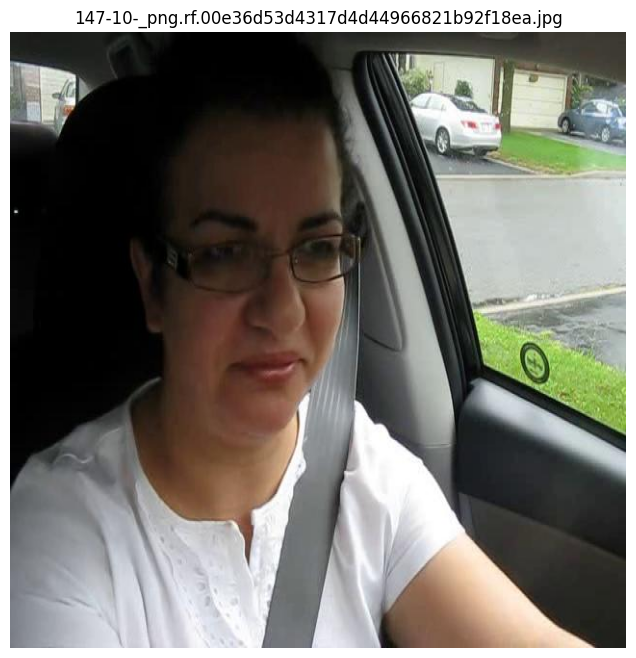

In [ ]:
# ==========================
# Display Test Image
# ==========================

image_path = image_paths[0]

image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))

plt.imshow(image_rgb)

plt.axis("off")

plt.title(os.path.basename(image_path))

plt.show()

In [ ]:
# ==========================
# YOLO Inference
# ==========================

start = time.time()

yolo_results = yolo_model.predict(
    source=image_path,
    conf=0.25,
    verbose=False
)

yolo_time = time.time() - start

print(f"YOLO Inference Time : {yolo_time:.4f} sec")

YOLO Inference Time : 0.0233 sec


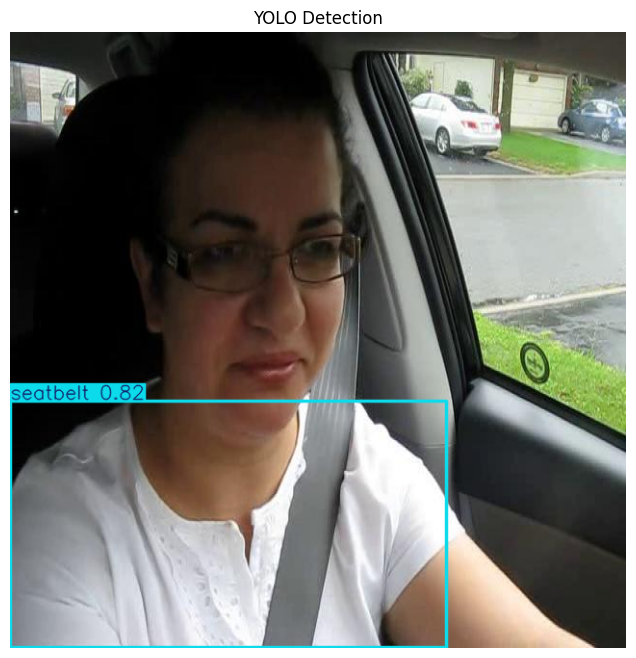

In [ ]:
# ==========================
# Show YOLO Result
# ==========================

yolo_image = yolo_results[0].plot()

plt.figure(figsize=(8,8))

plt.imshow(cv2.cvtColor(
    yolo_image,
    cv2.COLOR_BGR2RGB
))

plt.axis("off")

plt.title("YOLO Detection")

plt.show()

In [ ]:
# ==========================
# Faster R-CNN Inference
# ==========================

image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

image_tensor = F.to_tensor(
    image_rgb
).to(device)


start = time.time()

with torch.no_grad():

    prediction = faster_model(
        [image_tensor]
    )

faster_time = time.time() - start


print(f"Faster R-CNN Inference Time : {faster_time:.4f} sec")

Faster R-CNN Inference Time : 0.5209 sec


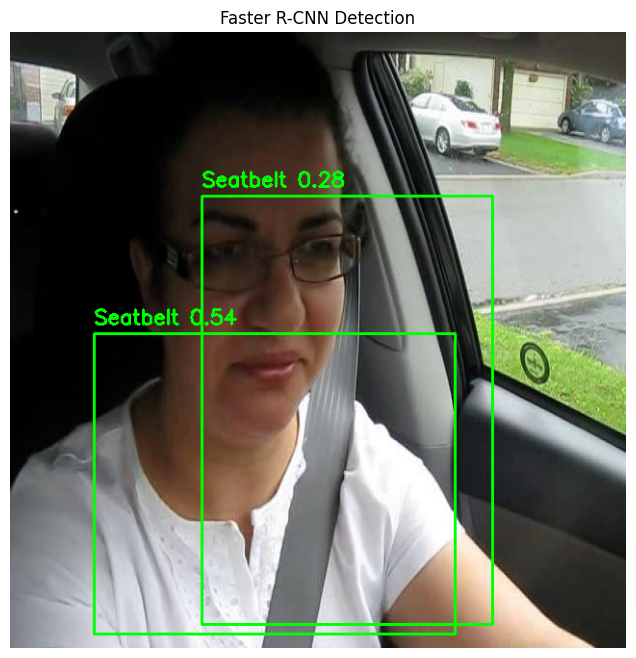

In [ ]:
# ==========================
# Draw Faster R-CNN Results
# ==========================

image_draw = image_rgb.copy()

boxes = prediction[0]["boxes"].cpu().numpy()
scores = prediction[0]["scores"].cpu().numpy()
labels = prediction[0]["labels"].cpu().numpy()


for box, score, label in zip(boxes, scores, labels):

    if score < 0.25:
        continue

    x1, y1, x2, y2 = box.astype(int)

    if label == 1:
        class_name = "Seatbelt"
        color = (0,255,0)

    elif label == 2:
        class_name = "No Seatbelt"
        color = (255,0,0)

    else:
        class_name = "Background"
        color = (255,255,255)

    cv2.rectangle(
        image_draw,
        (x1,y1),
        (x2,y2),
        color,
        2
    )

    cv2.putText(
        image_draw,
        f"{class_name} {score:.2f}",
        (x1,max(y1-10,20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        color,
        2
    )


plt.figure(figsize=(8,8))

plt.imshow(image_draw)

plt.axis("off")

plt.title("Faster R-CNN Detection")

plt.show()

In [ ]:
# ==========================
# Compare Inference Time
# ==========================

print("="*40)

print(f"YOLO Time           : {yolo_time:.4f} sec")

print(f"Faster R-CNN Time   : {faster_time:.4f} sec")

print("="*40)

YOLO Time           : 0.0233 sec
Faster R-CNN Time   : 0.5209 sec


In [ ]:
# ==========================
# Model Size Comparison
# ==========================

yolo_size = os.path.getsize(YOLO_MODEL_PATH) / (1024 * 1024)

faster_size = os.path.getsize(FASTER_MODEL_PATH) / (1024 * 1024)

print(f"YOLO Model Size         : {yolo_size:.2f} MB")
print(f"Faster R-CNN Model Size : {faster_size:.2f} MB")

YOLO Model Size         : 5.26 MB
Faster R-CNN Model Size : 158.07 MB


In [ ]:
# ==========================
# FPS Comparison
# ==========================

yolo_fps = 1 / yolo_time

faster_fps = 1 / faster_time

print(f"YOLO FPS         : {yolo_fps:.2f}")

print(f"Faster R-CNN FPS : {faster_fps:.2f}")

YOLO FPS         : 42.95
Faster R-CNN FPS : 1.92


In [ ]:
# ==========================
# Final Comparison
# ==========================

import pandas as pd

comparison = pd.DataFrame({

    "Metric": [

        "Inference Time (sec)",
        "FPS",
        "Model Size (MB)"

    ],

    "YOLO": [

        round(yolo_time,4),
        round(yolo_fps,2),
        round(yolo_size,2)

    ],

    "Faster R-CNN": [

        round(faster_time,4),
        round(faster_fps,2),
        round(faster_size,2)

    ]

})

comparison

,Metric,YOLO,Faster R-CNN
0,Inference Time (sec),0.0233,0.5209
1,FPS,42.9500,1.9200
2,Model Size (MB),5.2600,158.0700
